In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.calibration import calibration_curve

In [2]:
DATA_DIR = 'data/processed/'

# Load predictions and uncertainty from ensemble
guide_mean_probs = np.load(DATA_DIR + 'guide_mean_probs.npy')
guide_uncertainty = np.load(DATA_DIR + 'guide_uncertainty.npy')
change_mean_probs = np.load(DATA_DIR + 'change_mean_probs.npy')
change_uncertainty = np.load(DATA_DIR + 'change_uncertainty.npy')

# Load true labels
y_guide_test = np.load(DATA_DIR + 'y_guide_test.npy')
y_change_test = np.load(DATA_DIR + 'y_change_test.npy')

print(f'GUIDE-seq test: {len(y_guide_test)} samples, {y_guide_test.sum():.0f} positives')
print(f'CHANGE-seq test: {len(y_change_test)} samples, {y_change_test.sum():.0f} positives')

GUIDE-seq test: 248631 samples, 107 positives
CHANGE-seq test: 520991 samples, 6610 positives


## Performance Metrics

In [3]:
# AUROC and AUPRC for both datasets
print('GUIDE-seq (in-distribution):')
print(f'  AUROC: {roc_auc_score(y_guide_test, guide_mean_probs):.4f}')
print(f'  AUPRC: {average_precision_score(y_guide_test, guide_mean_probs):.4f}')
print(f'  Brier Score: {brier_score_loss(y_guide_test, guide_mean_probs):.4f}')

print('\nCHANGE-seq (out-of-distribution):')
print(f'  AUROC: {roc_auc_score(y_change_test, change_mean_probs):.4f}')
print(f'  AUPRC: {average_precision_score(y_change_test, change_mean_probs):.4f}')
print(f'  Brier Score: {brier_score_loss(y_change_test, change_mean_probs):.4f}')

GUIDE-seq (in-distribution):
  AUROC: 0.8285
  AUPRC: 0.0098
  Brier Score: 0.0039

CHANGE-seq (out-of-distribution):
  AUROC: 0.8519
  AUPRC: 0.0947
  Brier Score: 0.0137


### Results

The ensemble achieves AUROC of 0.83 on GUIDE-seq (in-distribution) and 0.85 on CHANGE-seq (out-of-distribution), outperforming all three baselines on both datasets. AUPRC is low for GUIDE-seq (0.0098) due to the extreme class imbalance (~99.96% negatives), but stronger on CHANGE-seq (0.0947) where positives are less rare. Brier scores are low across both datasets but should be interpreted cautiously under severe class imbalance, as a naive zero-predictor would also achieve a low score.

## ECE and Reliability Diagrams

In [4]:
def compute_ece(y_true, y_prob, n_bins=10):
    # Expected Calibration Error - weighted mean absolute deviation
    # between predicted confidence and empirical accuracy across bins
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    
    for i in range(n_bins):
        if i == n_bins - 1:
            mask = (y_prob >= bin_boundaries[i]) & (y_prob <= bin_boundaries[i+1])
        else:
            mask = (y_prob >= bin_boundaries[i]) & (y_prob < bin_boundaries[i+1])
        if mask.sum() == 0:
            continue
        bin_conf = y_prob[mask].mean()
        bin_acc = y_true[mask].mean()
        bin_weight = mask.sum() / len(y_true)
        ece += bin_weight * abs(bin_conf - bin_acc)
    
    return ece

In [5]:
guide_ece = compute_ece(y_guide_test, guide_mean_probs)
change_ece = compute_ece(y_change_test, change_mean_probs)

print(f'GUIDE-seq ECE: {guide_ece:.4f}')
print(f'CHANGE-seq ECE: {change_ece:.4f}')

GUIDE-seq ECE: 0.0473
CHANGE-seq ECE: 0.0370


### ECE Results Note
Unexpectedly, CHANGE-seq ECE (0.0370) is lower than GUIDE-seq ECE (0.0473). This likely reflects the model being trained on a 10:1 class ratio, which is closer to CHANGE-seq's real prevalence (~2.3% positives) than GUIDE-seq's (~0.04% positives).

## Reliability Diagrams

In [6]:
os.makedirs('results/', exist_ok=True)

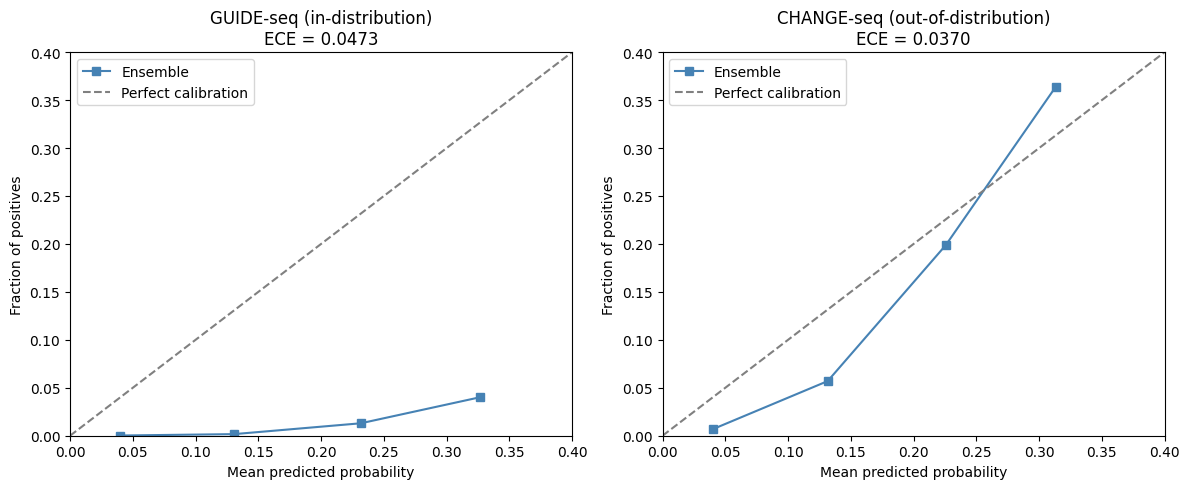

In [8]:
def plot_reliability_diagram(y_true, y_prob, title, n_bins=10, ax=None):
    # Plot predicted confidence vs empirical accuracy across bins
    fraction_of_positives, mean_predicted_value = calibration_curve(
        y_true, y_prob, n_bins=n_bins, strategy='uniform'
    )
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    
    ax.plot(mean_predicted_value, fraction_of_positives, 
            's-', label='Ensemble', color='steelblue')
    ax.plot([0, 1], [0, 1], '--', label='Perfect calibration', color='grey')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.set_title(title)
    ax.legend()
    ax.set_xlim([0, 0.4])
    ax.set_ylim([0, 0.4])
    
    return ax

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_reliability_diagram(
    y_guide_test, guide_mean_probs,
    f'GUIDE-seq (in-distribution)\nECE = {guide_ece:.4f}',
    ax=axes[0]
)

plot_reliability_diagram(
    y_change_test, change_mean_probs,
    f'CHANGE-seq (out-of-distribution)\nECE = {change_ece:.4f}',
    ax=axes[1]
)

plt.tight_layout()
plt.savefig('results/reliability_diagrams.png', dpi=150, bbox_inches='tight')
plt.show()

### Results
ECE measures the weighted mean absolute deviation between predicted confidence and empirical accuracy across probability bins. Reliability diagrams plot predicted probability against the fraction of true positives in each bin. A perfectly calibrated model would follow the diagonal.

GUIDE-seq ECE (0.0473) is higher than CHANGE-seq ECE (0.0370), which is attributed to the more extreme class imbalance in GUIDE-seq (~0.04% positives) compared to CHANGE-seq (~2.3% positives). The reliability diagrams confirm this: GUIDE-seq shows severe underestimation of positive rates across all confidence levels, while CHANGE-seq tracks closer to the diagonal. Both datasets show predictions concentrated below 0.35, indicating the model is appropriately uncertain but systematically underestimates cleavage probability.

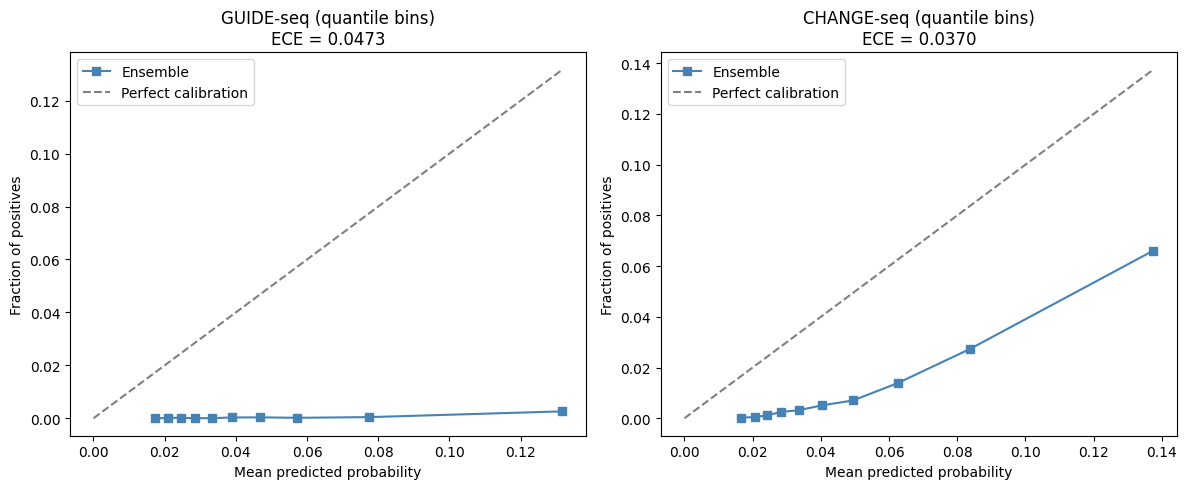

In [9]:
def plot_reliability_diagram_quantile(y_true, y_prob, title, n_bins=10, ax=None):
    # Quantile binning - equal number of samples per bin
    # Better reveals calibration in dense low-probability regions
    quantiles = np.percentile(y_prob, np.linspace(0, 100, n_bins + 1))
    quantiles = np.unique(quantiles)
    
    bin_confs = []
    bin_accs = []
    
    for i in range(len(quantiles) - 1):
        if i == len(quantiles) - 2:
            mask = (y_prob >= quantiles[i]) & (y_prob <= quantiles[i+1])
        else:
            mask = (y_prob >= quantiles[i]) & (y_prob < quantiles[i+1])
        if mask.sum() == 0:
            continue
        bin_confs.append(y_prob[mask].mean())
        bin_accs.append(y_true[mask].mean())
    
    bin_confs = np.array(bin_confs)
    bin_accs = np.array(bin_accs)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    
    ax.plot(bin_confs, bin_accs, 's-', label='Ensemble', color='steelblue')
    ax.plot([0, bin_confs.max()], [0, bin_confs.max()], 
            '--', label='Perfect calibration', color='grey')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.set_title(title)
    ax.legend()
    
    return ax

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_reliability_diagram_quantile(
    y_guide_test, guide_mean_probs,
    f'GUIDE-seq (quantile bins)\nECE = {guide_ece:.4f}',
    ax=axes[0]
)

plot_reliability_diagram_quantile(
    y_change_test, change_mean_probs,
    f'CHANGE-seq (quantile bins)\nECE = {change_ece:.4f}',
    ax=axes[1]
)

plt.tight_layout()
plt.savefig('results/reliability_diagrams_quantile.png', dpi=150, bbox_inches='tight')
plt.show()

### Quantile Reliability Diagrams

Quantile binning places equal numbers of samples in each bin, exposing calibration behaviour in the dense low-probability region. GUIDE-seq shows near-zero fraction of positives across all bins despite increasing predicted probabilities, indicating the model's scores carry little discriminative information about true positives at the real class prevalence. CHANGE-seq shows a clearer monotonic relationship between predicted probability and positive rate, consistent with its lower ECE and closer match to the training class ratio.